# StormEngine — Seasonal Analysis of MSL and Wind Gust (i10fg) — Full Year 2024

Seasonal analysis of **mean sea level pressure (msl)** and **instantaneous 10m wind gust (i10fg)** across the entire 2024 calendar year, built directly from the 12 monthly NetCDF files.

## File structure
Each NetCDF covers one calendar month at 0.25° resolution over the domain `[39–46.5°N, 12–20°E]`:
- `msl`, `u10`, `v10`, `i10fg` — hourly, dims `(valid_time, latitude, longitude)`
- `msl` converted from **Pa → hPa** (÷100); `i10fg` requires **no conversion** (already in m/s)

All four seasons (Winter, Spring, Summer, Autumn) are covered for both variables.

## 0. Imports and Configuration

In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 11, 'font.family': 'sans-serif',
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.7,
    'legend.frameon': False,
})

PROJECT_ROOT = r'D:\StormEngine'
DATA_DIR     = os.path.join(PROJECT_ROOT, 'dati_storici', 'estratto_std')

LAT_MIN, LAT_MAX = 39.0, 46.5
LON_MIN, LON_MAX = 12.0, 20.0
PA_TO_HPA = 1.0 / 100.0

MONTH_NAMES = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
SEASON_MAP = {12:'Winter', 1:'Winter', 2:'Winter',
              3:'Spring', 4:'Spring', 5:'Spring',
              6:'Summer', 7:'Summer', 8:'Summer',
              9:'Autumn', 10:'Autumn', 11:'Autumn'}

MONTH_COLORS = {m: c for m, c in zip(MONTH_NAMES, plt.cm.tab20(np.linspace(0, 1, 12)))}
SEASON_COLORS = {'Winter': '#08519c', 'Spring': '#41ab5d',
                  'Summer': '#cb181d', 'Autumn': '#fb8d3d'}

print('Configuration loaded.')
print(f'Data directory: {DATA_DIR}')

Configuration loaded.
Data directory: D:\StormEngine\dati_storici\estratto_std


## 1. Load and Verify All 12 Monthly NetCDF Files

In [6]:
nc_files = [
    os.path.join(DATA_DIR, f'era5_std_adriatico_2024_{month:02d}.nc')
    for month in range(1, 13)
]

print(f'Looking in: {DATA_DIR}')
print(f'Expected {len(nc_files)} monthly files:')
missing = []
for f in nc_files:
    exists = os.path.isfile(f)
    print(f'  {"OK" if exists else "MISSING":8s} {f}')
    if not exists:
        missing.append(f)

assert not missing, f'Missing {len(missing)} file(s): {missing}'

datasets = [xr.open_dataset(f) for f in nc_files]
ds_year = xr.concat(datasets, dim='valid_time')
ds_year = ds_year.sortby('valid_time')

print(f'\nConcatenated dataset:')
print(f'  Total hours : {ds_year.sizes["valid_time"]}  (expected 8784 for 2024, leap year)')
print(f'  Grid        : {ds_year.sizes["latitude"]} x {ds_year.sizes["longitude"]}')
print(f'  Time range  : {ds_year.valid_time.values[0]} -> {ds_year.valid_time.values[-1]}')
print(f'  Variables   : {list(ds_year.data_vars)}')

Looking in: D:\StormEngine\dati_storici\estratto_std
Expected 12 monthly files:
  OK       D:\StormEngine\dati_storici\estratto_std\era5_std_adriatico_2024_01.nc
  OK       D:\StormEngine\dati_storici\estratto_std\era5_std_adriatico_2024_02.nc
  OK       D:\StormEngine\dati_storici\estratto_std\era5_std_adriatico_2024_03.nc
  OK       D:\StormEngine\dati_storici\estratto_std\era5_std_adriatico_2024_04.nc
  OK       D:\StormEngine\dati_storici\estratto_std\era5_std_adriatico_2024_05.nc
  OK       D:\StormEngine\dati_storici\estratto_std\era5_std_adriatico_2024_06.nc
  OK       D:\StormEngine\dati_storici\estratto_std\era5_std_adriatico_2024_07.nc
  OK       D:\StormEngine\dati_storici\estratto_std\era5_std_adriatico_2024_08.nc
  OK       D:\StormEngine\dati_storici\estratto_std\era5_std_adriatico_2024_09.nc
  OK       D:\StormEngine\dati_storici\estratto_std\era5_std_adriatico_2024_10.nc
  OK       D:\StormEngine\dati_storici\estratto_std\era5_std_adriatico_2024_11.nc
  OK       D:\Stor

## 2. Extract MSL, Convert Units, and Split by Month

Extracts the `msl` variable, converts Pa → hPa, and reorganises the continuous yearly array into one entry per calendar month.

In [7]:
# Convert MSL to hPa
msl_year = ds_year['msl'].values * PA_TO_HPA          # (n_hours, n_lat, n_lon)
valid_times = pd.DatetimeIndex(ds_year['valid_time'].values)
lats = ds_year['latitude'].values
lons = ds_year['longitude'].values

print(f'MSL array shape : {msl_year.shape}  (hours, lat, lon)')
print(f'Domain mean MSL : {np.nanmean(msl_year):.2f} hPa')

n_hours = msl_year.shape[0]
n_points = msl_year.shape[1] * msl_year.shape[2]
samples_flat_msl = msl_year.reshape(n_hours, n_points).T   # (n_points, n_hours)

lon_grid, lat_grid = np.meshgrid(lons, lats)
lon_flat = lon_grid.flatten()
lat_flat = lat_grid.flatten()

months_idx = valid_times.month

data_msl = {}
for m in range(1, 13):
    mask = months_idx == m
    month_name = MONTH_NAMES[m-1]
    data_msl[month_name] = {
        'value'   : np.nanmean(samples_flat_msl[:, mask], axis=1),
        'samples' : samples_flat_msl[:, mask],
        'lon'     : lon_flat,
        'lat'     : lat_flat,
        'n_points': n_points,
        'n_hours' : int(mask.sum()),
        'season'  : SEASON_MAP[m],
    }
    print(f'{month_name:10s} | season={SEASON_MAP[m]:7s} | '
          f'points={n_points} | hours={mask.sum()} | '
          f'domain mean={data_msl[month_name]["samples"].mean():.2f} hPa')

MSL array shape : (8784, 31, 33)  (hours, lat, lon)
Domain mean MSL : 1016.06 hPa
January    | season=Winter  | points=1023 | hours=744 | domain mean=1019.27 hPa
February   | season=Winter  | points=1023 | hours=696 | domain mean=1016.90 hPa
March      | season=Spring  | points=1023 | hours=744 | domain mean=1013.10 hPa
April      | season=Spring  | points=1023 | hours=720 | domain mean=1015.79 hPa
May        | season=Spring  | points=1023 | hours=744 | domain mean=1013.75 hPa
June       | season=Summer  | points=1023 | hours=720 | domain mean=1013.75 hPa
July       | season=Summer  | points=1023 | hours=744 | domain mean=1012.70 hPa
August     | season=Summer  | points=1023 | hours=744 | domain mean=1012.90 hPa
September  | season=Autumn  | points=1023 | hours=720 | domain mean=1013.50 hPa
October    | season=Autumn  | points=1023 | hours=744 | domain mean=1019.00 hPa
November   | season=Autumn  | points=1023 | hours=720 | domain mean=1021.68 hPa
December   | season=Winter  | points=1

## 2bis. Extract i10fg and Split by Month

Same procedure as Step 2, applied to `i10fg` (instantaneous 10m wind gust). No unit conversion is needed — the variable is already expressed in m/s.

In [8]:
# i10fg requires no unit conversion (already m/s)
i10fg_year = ds_year['i10fg'].values                   # (n_hours, n_lat, n_lon)

print(f'i10fg array shape : {i10fg_year.shape}  (hours, lat, lon)')
print(f'Domain mean i10fg : {np.nanmean(i10fg_year):.2f} m/s')

samples_flat_i10fg = i10fg_year.reshape(n_hours, n_points).T   # (n_points, n_hours)

data_i10fg = {}
for m in range(1, 13):
    mask = months_idx == m
    month_name = MONTH_NAMES[m-1]
    data_i10fg[month_name] = {
        'value'   : np.nanmean(samples_flat_i10fg[:, mask], axis=1),
        'samples' : samples_flat_i10fg[:, mask],
        'lon'     : lon_flat,
        'lat'     : lat_flat,
        'n_points': n_points,
        'n_hours' : int(mask.sum()),
        'season'  : SEASON_MAP[m],
    }
    print(f'{month_name:10s} | season={SEASON_MAP[m]:7s} | '
          f'points={n_points} | hours={mask.sum()} | '
          f'domain mean={data_i10fg[month_name]["samples"].mean():.2f} m/s')

i10fg array shape : (8784, 31, 33)  (hours, lat, lon)
Domain mean i10fg : 6.11 m/s
January    | season=Winter  | points=1023 | hours=744 | domain mean=7.07 m/s
February   | season=Winter  | points=1023 | hours=696 | domain mean=6.57 m/s
March      | season=Spring  | points=1023 | hours=744 | domain mean=6.89 m/s
April      | season=Spring  | points=1023 | hours=720 | domain mean=6.19 m/s
May        | season=Spring  | points=1023 | hours=744 | domain mean=5.75 m/s
June       | season=Summer  | points=1023 | hours=720 | domain mean=5.36 m/s
July       | season=Summer  | points=1023 | hours=744 | domain mean=5.28 m/s
August     | season=Summer  | points=1023 | hours=744 | domain mean=4.79 m/s
September  | season=Autumn  | points=1023 | hours=720 | domain mean=6.50 m/s
October    | season=Autumn  | points=1023 | hours=744 | domain mean=5.62 m/s
November   | season=Autumn  | points=1023 | hours=720 | domain mean=6.24 m/s
December   | season=Winter  | points=1023 | hours=744 | domain mean=7.

## 3. Summary Statistics per Month — MSL

Domain-averaged statistics: each hourly sample is first averaged over all grid points, giving one time series per month, then summarised.

In [9]:
rows = []
for month, d in data_msl.items():
    ts = np.nanmean(d['samples'], axis=0)
    rows.append({
        'Month'  : month,
        'Season' : d['season'],
        'Mean'   : np.mean(ts),
        'Std'    : np.std(ts),
        'Min'    : np.min(ts),
        'Max'    : np.max(ts),
        'Range'  : np.max(ts) - np.min(ts),
        'Median' : np.median(ts),
    })

summary_msl = pd.DataFrame(rows).set_index('Month').round(2)
print('Domain-averaged MSL statistics (hPa)\n')
print(summary_msl.to_string())

Domain-averaged MSL statistics (hPa)

           Season         Mean    Std          Min          Max      Range       Median
Month                                                                                  
January    Winter  1019.270020  10.95   995.469971  1037.099976  41.630001  1020.530029
February   Winter  1016.900024   8.86   994.869995  1031.780029  36.910000  1019.030029
March      Spring  1013.099976   5.60   996.690002  1023.479980  26.790001  1013.549988
April      Spring  1015.789978   6.20  1002.719971  1027.949951  25.219999  1016.700012
May        Spring  1013.750000   3.04  1006.739990  1019.119995  12.380000  1014.119995
June       Summer  1013.750000   2.70  1006.429993  1018.400024  11.970000  1014.150024
July       Summer  1012.700012   2.62  1005.789978  1018.039978  12.250000  1012.780029
August     Summer  1012.900024   2.78  1006.599976  1019.090027  12.490000  1012.890015
September  Autumn  1013.500000   4.04  1003.909973  1022.830017  18.910000  1013.3

## 3bis. Summary Statistics per Month — i10fg

In [10]:
rows = []
for month, d in data_i10fg.items():
    ts = np.nanmean(d['samples'], axis=0)
    rows.append({
        'Month'  : month,
        'Season' : d['season'],
        'Mean'   : np.mean(ts),
        'Std'    : np.std(ts),
        'Min'    : np.min(ts),
        'Max'    : np.max(ts),
        'Range'  : np.max(ts) - np.min(ts),
        'Median' : np.median(ts),
    })

summary_i10fg = pd.DataFrame(rows).set_index('Month').round(2)
print('Domain-averaged i10fg statistics (m/s)\n')
print(summary_i10fg.to_string())

Domain-averaged i10fg statistics (m/s)

           Season  Mean   Std   Min    Max  Range  Median
Month                                                    
January    Winter  7.07  2.03  3.71  12.73   9.01    6.68
February   Winter  6.57  2.63  2.48  14.64  12.16    6.01
March      Spring  6.89  2.48  2.74  14.77  12.03    6.38
April      Spring  6.19  2.05  3.18  13.63  10.46    5.79
May        Spring  5.75  1.94  2.49  11.28   8.79    5.56
June       Summer  5.36  1.36  3.10   9.99   6.90    5.19
July       Summer  5.28  1.31  2.96   9.53   6.57    5.26
August     Summer  4.79  1.09  2.61   7.67   5.06    4.65
September  Autumn  6.50  2.25  2.81  12.08   9.27    6.13
October    Autumn  5.62  2.14  2.58  13.68  11.09    4.91
November   Autumn  6.24  2.67  3.03  16.07  13.04    5.61
December   Winter  7.11  3.12  2.33  15.01  12.68    6.37


## 4. Monthly Time Series — Domain-Averaged MSL

Hourly evolution of the domain-mean pressure for each month, revealing the passage of synoptic systems.

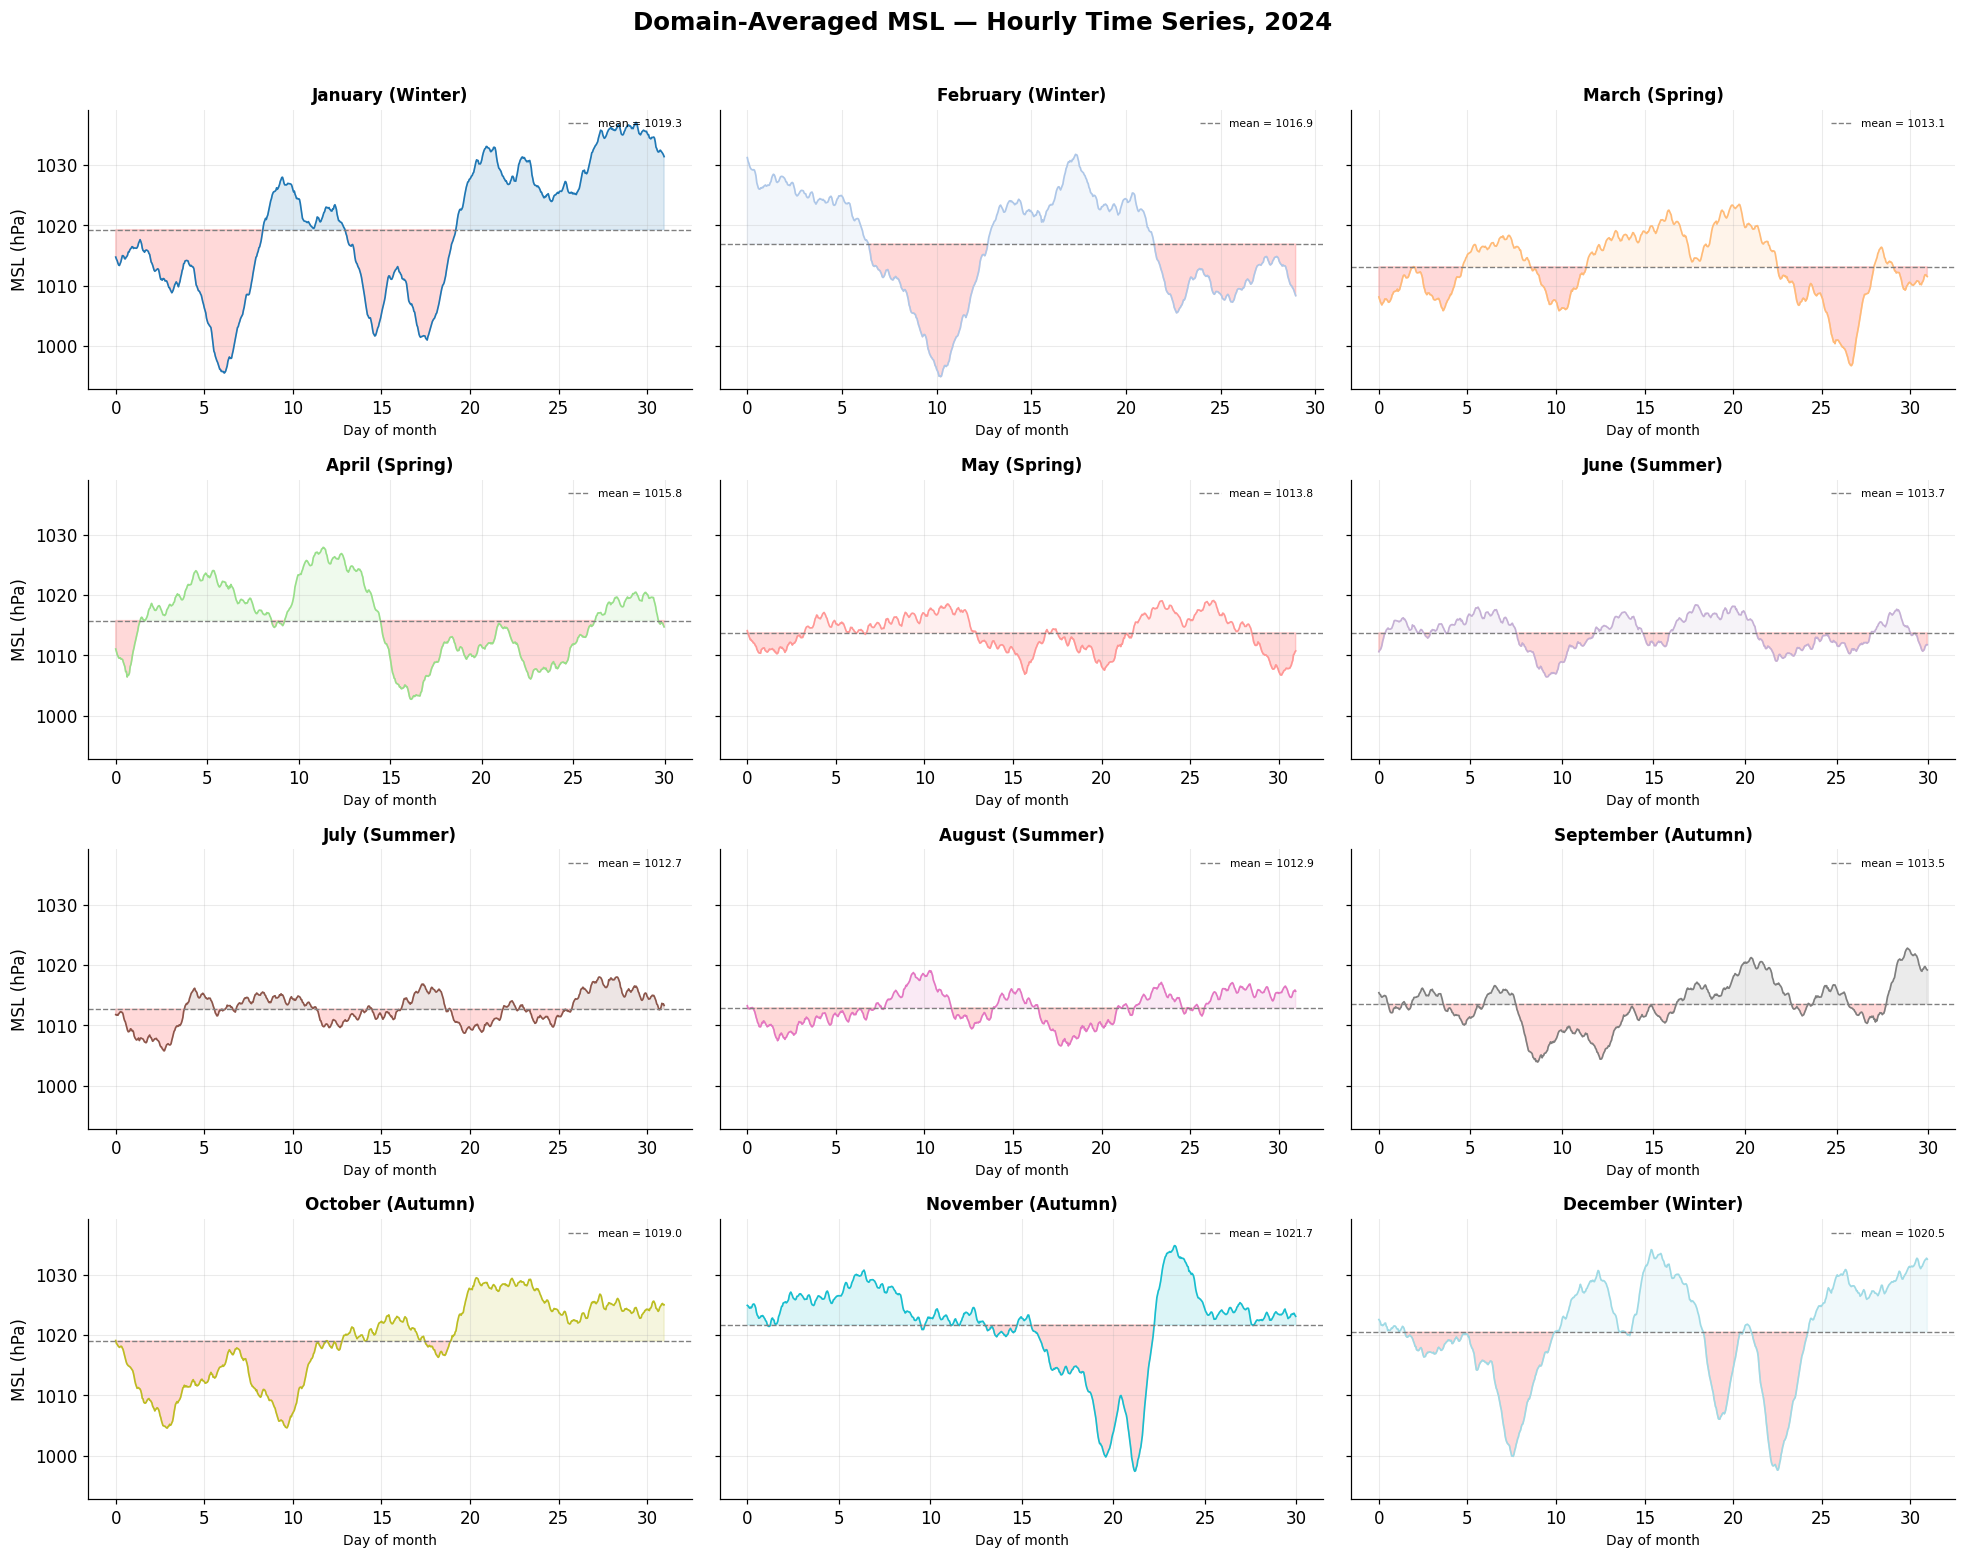

In [11]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14), sharey=True)
axes = axes.flatten()

for ax, (month, d) in zip(axes, data_msl.items()):
    ts   = np.nanmean(d['samples'], axis=0)
    days = np.arange(len(ts)) / 24.0

    ax.plot(days, ts, color=MONTH_COLORS[month], linewidth=1.1)
    ax.axhline(ts.mean(), color='gray', linestyle='--', linewidth=0.9,
               label=f'mean = {ts.mean():.1f}')
    ax.fill_between(days, ts, ts.mean(), where=(ts >= ts.mean()),
                    alpha=0.15, color=MONTH_COLORS[month])
    ax.fill_between(days, ts, ts.mean(), where=(ts < ts.mean()),
                    alpha=0.15, color='red')

    ax.set_title(f'{month} ({d["season"]})', fontsize=11)
    ax.set_xlabel('Day of month', fontsize=9)
    ax.legend(loc='upper right', fontsize=7)

for i in range(0, len(axes), 3):
    axes[i].set_ylabel('MSL (hPa)')

fig.suptitle('Domain-Averaged MSL — Hourly Time Series, 2024',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('msl_monthly_timeseries_2024.png', bbox_inches='tight')
plt.show()

## 4bis. Monthly Time Series — Domain-Averaged i10fg

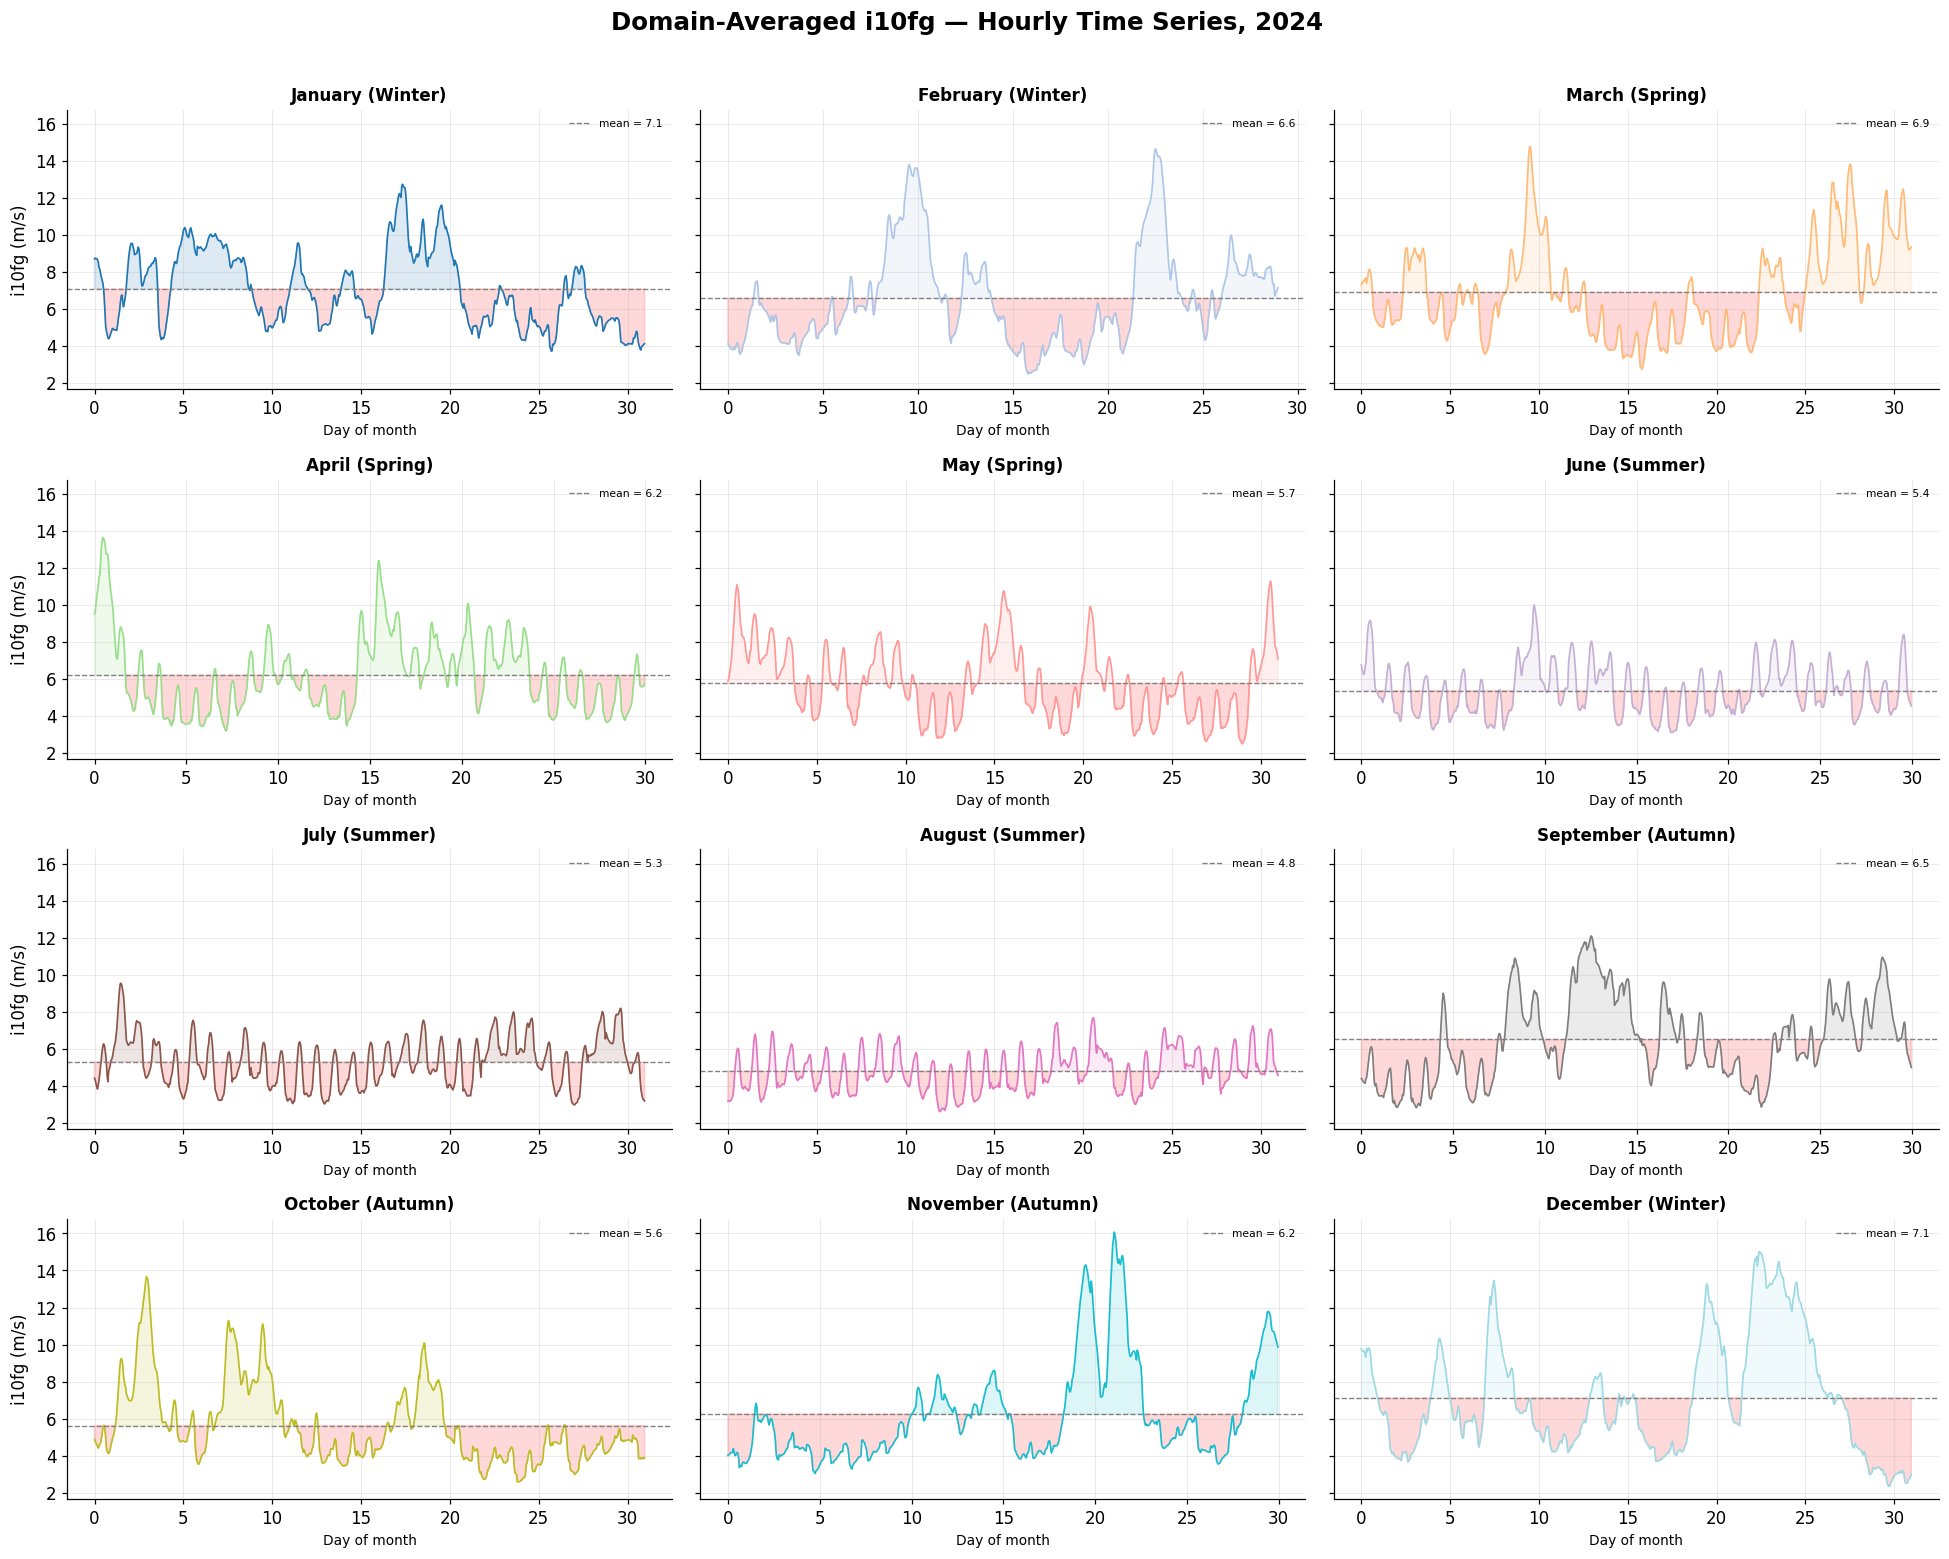

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14), sharey=True)
axes = axes.flatten()

for ax, (month, d) in zip(axes, data_i10fg.items()):
    ts   = np.nanmean(d['samples'], axis=0)
    days = np.arange(len(ts)) / 24.0

    ax.plot(days, ts, color=MONTH_COLORS[month], linewidth=1.1)
    ax.axhline(ts.mean(), color='gray', linestyle='--', linewidth=0.9,
               label=f'mean = {ts.mean():.1f}')
    ax.fill_between(days, ts, ts.mean(), where=(ts >= ts.mean()),
                    alpha=0.15, color=MONTH_COLORS[month])
    ax.fill_between(days, ts, ts.mean(), where=(ts < ts.mean()),
                    alpha=0.15, color='red')

    ax.set_title(f'{month} ({d["season"]})', fontsize=11)
    ax.set_xlabel('Day of month', fontsize=9)
    ax.legend(loc='upper right', fontsize=7)

for i in range(0, len(axes), 3):
    axes[i].set_ylabel('i10fg (m/s)')

fig.suptitle('Domain-Averaged i10fg — Hourly Time Series, 2024',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('i10fg_monthly_timeseries_2024.png', bbox_inches='tight')
plt.show()

## 5. Aggregated Continuous Time Series — Full Year (MSL)

All 12 months placed on a single continuous hourly timeline, in chronological order.

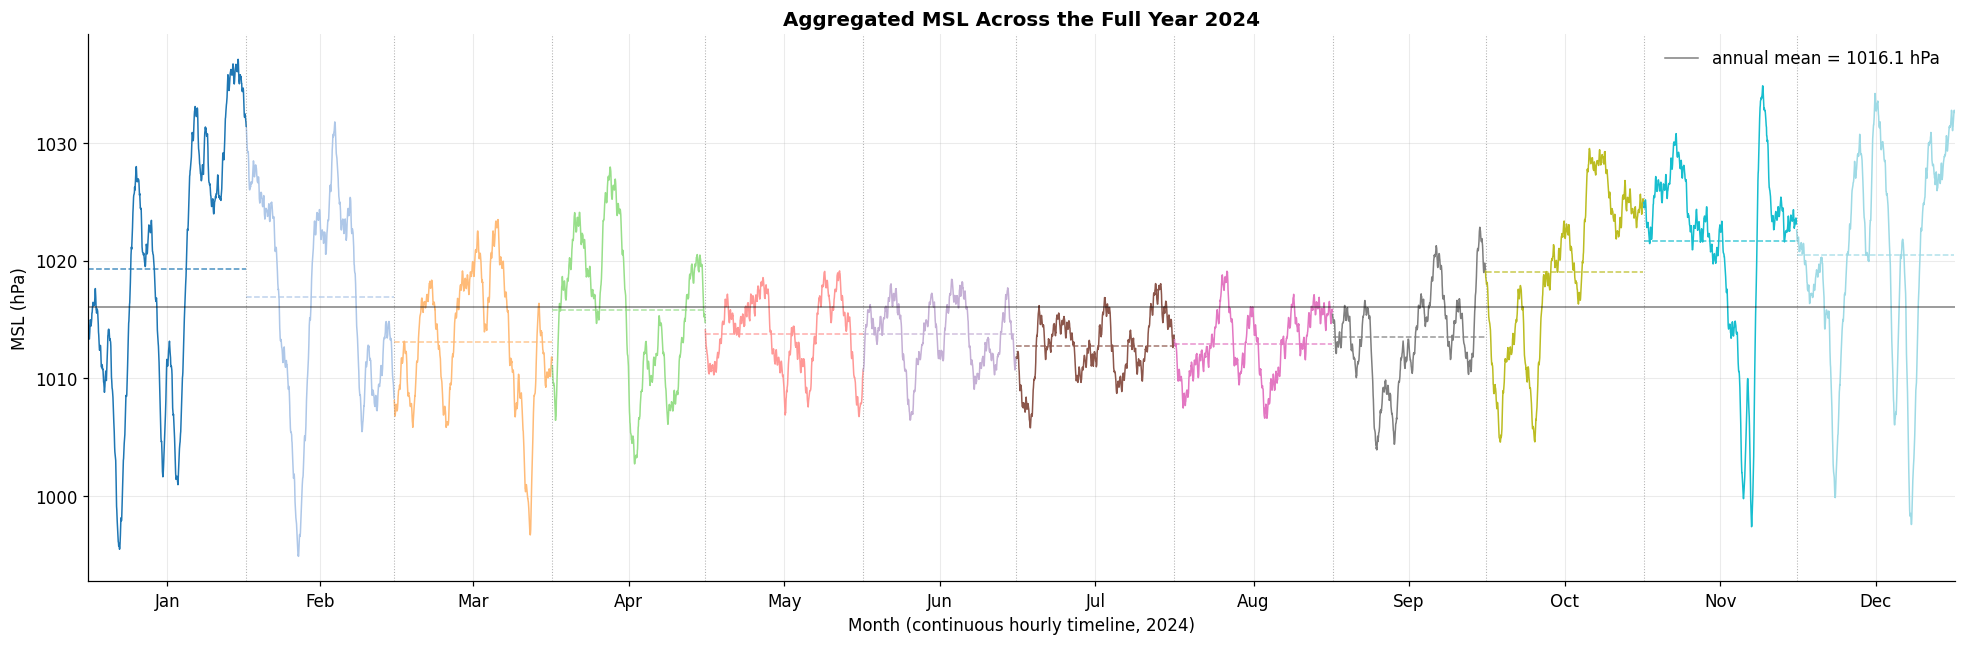

In [13]:
fig, ax = plt.subplots(figsize=(18, 6))

cursor = 0
boundaries = []
tick_pos = []
tick_lab = []

for month in MONTH_NAMES:
    d = data_msl[month]
    ts = np.nanmean(d['samples'], axis=0)
    days = cursor + np.arange(len(ts)) / 24.0

    ax.plot(days, ts, color=MONTH_COLORS[month], linewidth=1.0)
    ax.hlines(ts.mean(), days[0], days[-1],
              color=MONTH_COLORS[month], linestyle='--', linewidth=1.0, alpha=0.8)

    tick_pos.append(cursor + len(ts)/24.0 / 2)
    tick_lab.append(month[:3])
    cursor += len(ts) / 24.0
    boundaries.append(cursor)

for b in boundaries[:-1]:
    ax.axvline(b, color='gray', linestyle=':', linewidth=0.7, alpha=0.6)

global_mean_msl = np.concatenate([np.nanmean(d['samples'], axis=0) for d in data_msl.values()]).mean()
ax.axhline(global_mean_msl, color='black', linewidth=1, alpha=0.5,
           label=f'annual mean = {global_mean_msl:.1f} hPa')

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lab)
ax.set_xlim(0, cursor)
ax.set_ylabel('MSL (hPa)')
ax.set_xlabel('Month (continuous hourly timeline, 2024)')
ax.set_title('Aggregated MSL Across the Full Year 2024')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('msl_aggregated_timeline_2024.png', bbox_inches='tight')
plt.show()

## 5bis. Aggregated Continuous Time Series — Full Year (i10fg)

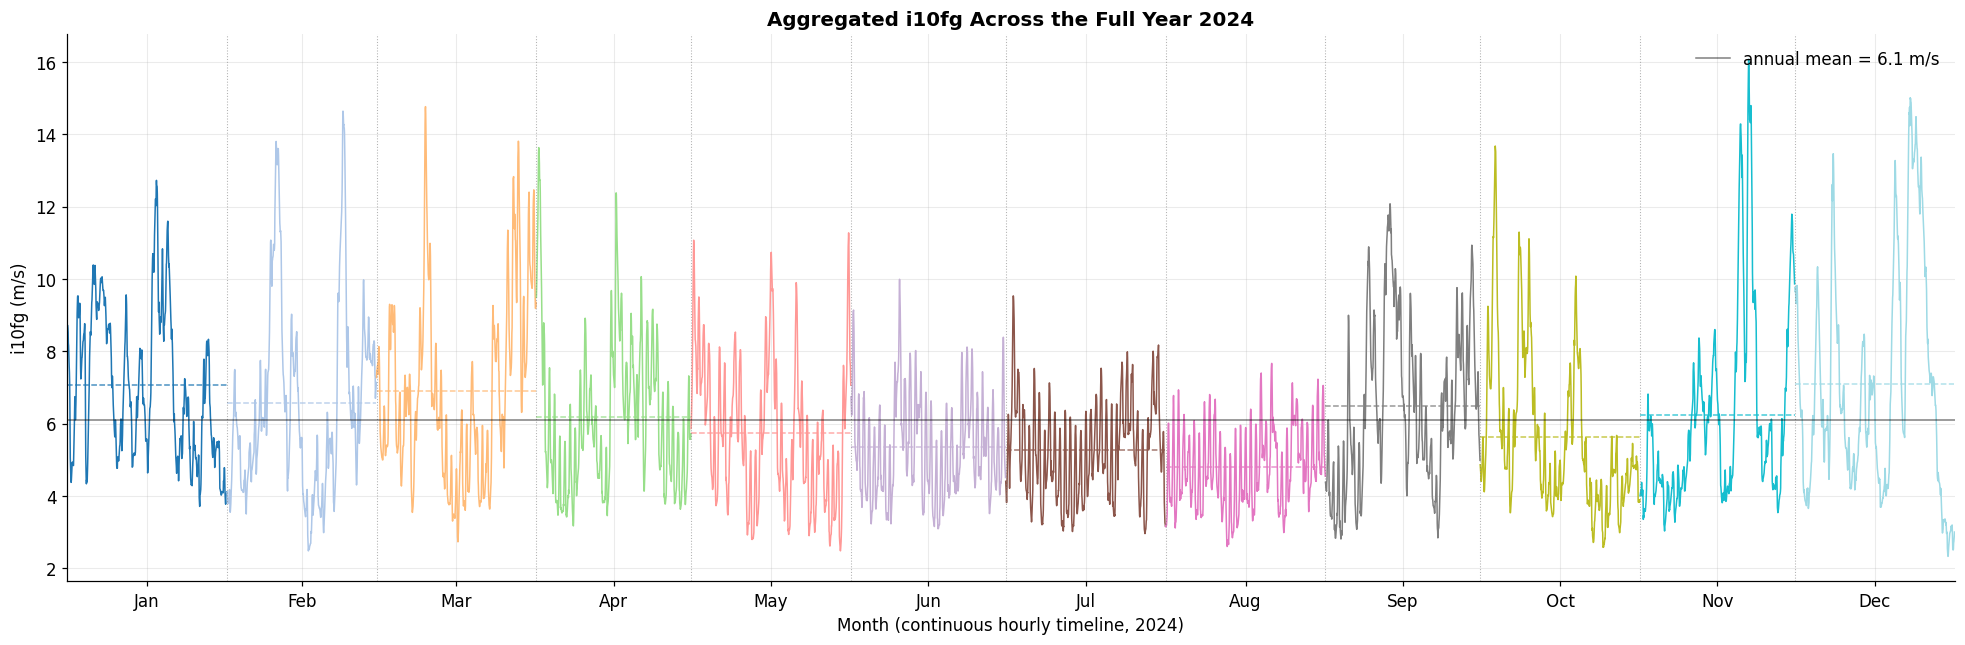

In [14]:
fig, ax = plt.subplots(figsize=(18, 6))

cursor = 0
boundaries = []
tick_pos = []
tick_lab = []

for month in MONTH_NAMES:
    d = data_i10fg[month]
    ts = np.nanmean(d['samples'], axis=0)
    days = cursor + np.arange(len(ts)) / 24.0

    ax.plot(days, ts, color=MONTH_COLORS[month], linewidth=1.0)
    ax.hlines(ts.mean(), days[0], days[-1],
              color=MONTH_COLORS[month], linestyle='--', linewidth=1.0, alpha=0.8)

    tick_pos.append(cursor + len(ts)/24.0 / 2)
    tick_lab.append(month[:3])
    cursor += len(ts) / 24.0
    boundaries.append(cursor)

for b in boundaries[:-1]:
    ax.axvline(b, color='gray', linestyle=':', linewidth=0.7, alpha=0.6)

global_mean_i10fg = np.concatenate([np.nanmean(d['samples'], axis=0) for d in data_i10fg.values()]).mean()
ax.axhline(global_mean_i10fg, color='black', linewidth=1, alpha=0.5,
           label=f'annual mean = {global_mean_i10fg:.1f} m/s')

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lab)
ax.set_xlim(0, cursor)
ax.set_ylabel('i10fg (m/s)')
ax.set_xlabel('Month (continuous hourly timeline, 2024)')
ax.set_title('Aggregated i10fg Across the Full Year 2024')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('i10fg_aggregated_timeline_2024.png', bbox_inches='tight')
plt.show()

## 6. Distribution Comparison — Violin + Box Plots (MSL)

Distribution of all hourly domain-mean values per month, across the full year.

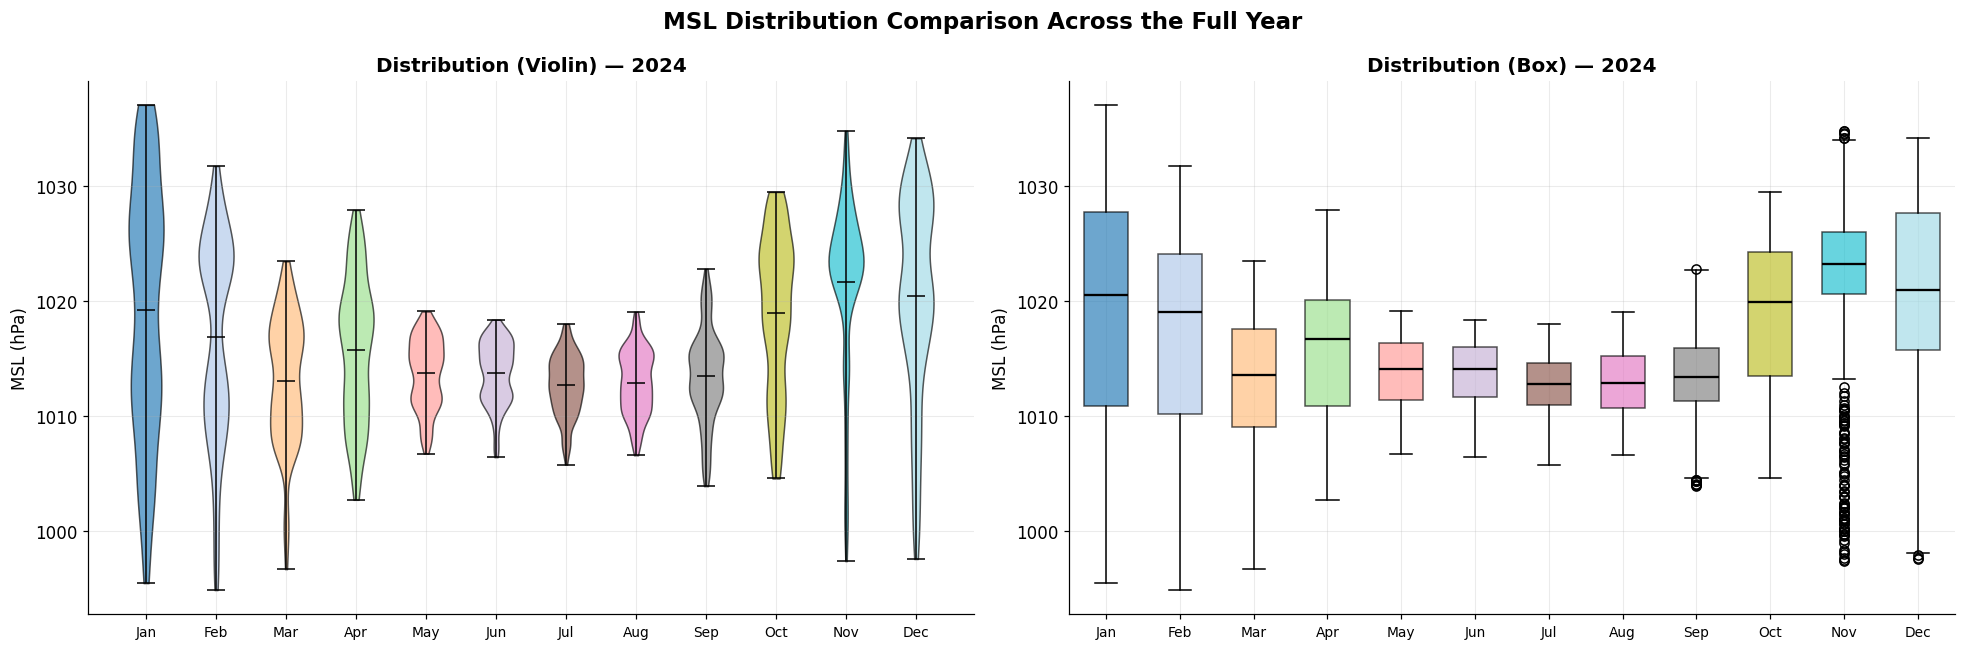

In [15]:
months = MONTH_NAMES
ts_all_msl = [np.nanmean(data_msl[m]['samples'], axis=0) for m in months]
colors     = [MONTH_COLORS[m] for m in months]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

parts = ax1.violinplot(ts_all_msl, showmeans=True, showmedians=False)
for pc, c in zip(parts['bodies'], colors):
    pc.set_facecolor(c); pc.set_alpha(0.65); pc.set_edgecolor('black')
for key in ['cmeans', 'cmaxes', 'cmins', 'cbars']:
    if key in parts:
        parts[key].set_edgecolor('black'); parts[key].set_linewidth(1.0)
ax1.set_xticks(range(1, len(months)+1))
ax1.set_xticklabels([m[:3] for m in months], fontsize=9)
ax1.set_ylabel('MSL (hPa)')
ax1.set_title('Distribution (Violin) — 2024')

bp = ax2.boxplot(ts_all_msl, patch_artist=True, widths=0.6,
                 medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.65)
ax2.set_xticks(range(1, len(months)+1))
ax2.set_xticklabels([m[:3] for m in months], fontsize=9)
ax2.set_ylabel('MSL (hPa)')
ax2.set_title('Distribution (Box) — 2024')

fig.suptitle('MSL Distribution Comparison Across the Full Year',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('msl_distributions_2024.png', bbox_inches='tight')
plt.show()

## 6bis. Distribution Comparison — Violin + Box Plots (i10fg)

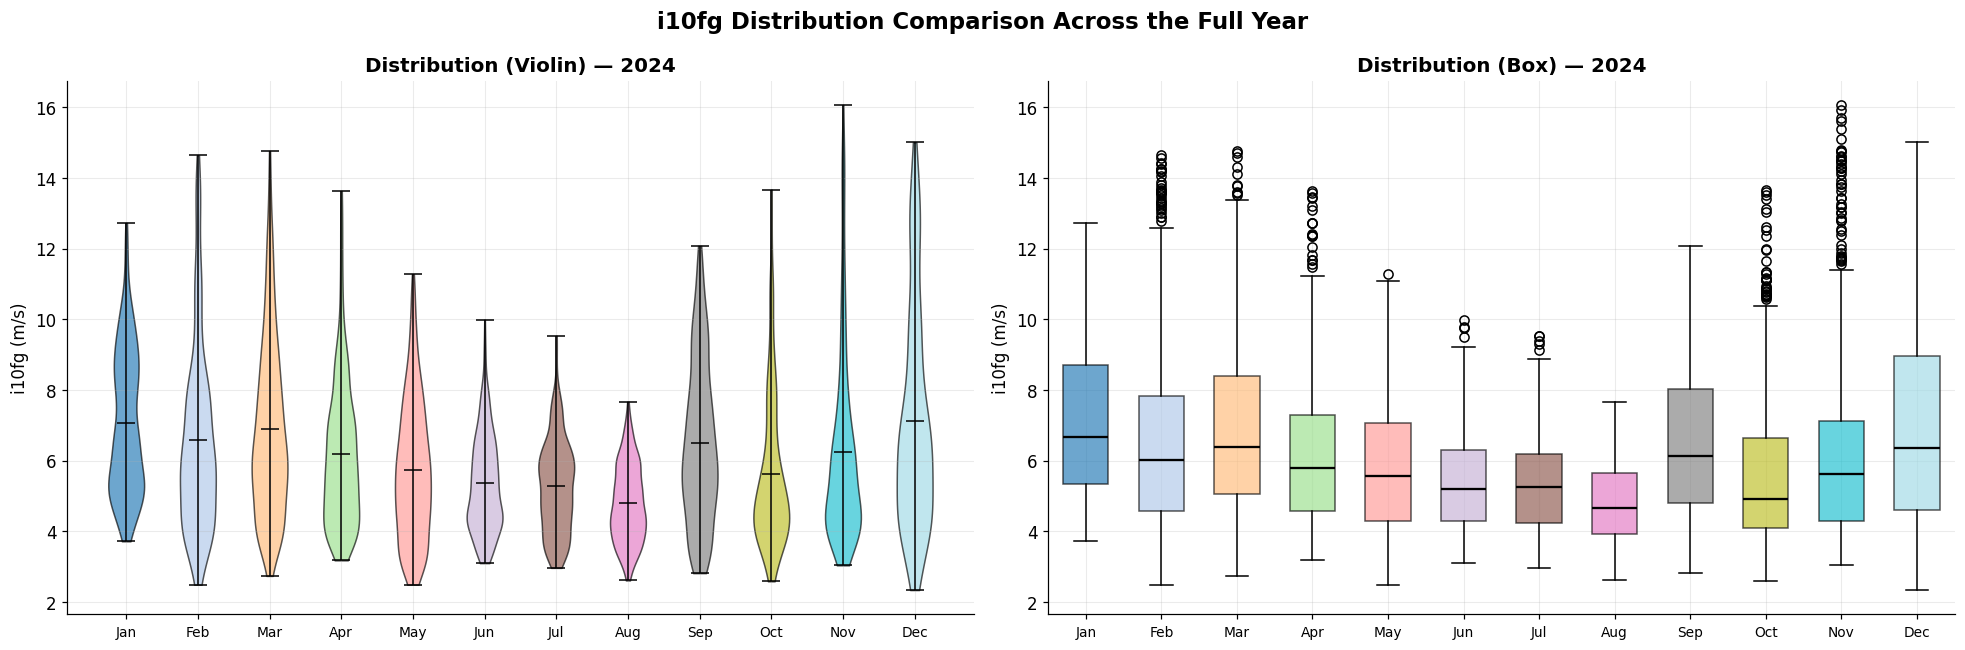

In [16]:
ts_all_i10fg = [np.nanmean(data_i10fg[m]['samples'], axis=0) for m in months]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

parts = ax1.violinplot(ts_all_i10fg, showmeans=True, showmedians=False)
for pc, c in zip(parts['bodies'], colors):
    pc.set_facecolor(c); pc.set_alpha(0.65); pc.set_edgecolor('black')
for key in ['cmeans', 'cmaxes', 'cmins', 'cbars']:
    if key in parts:
        parts[key].set_edgecolor('black'); parts[key].set_linewidth(1.0)
ax1.set_xticks(range(1, len(months)+1))
ax1.set_xticklabels([m[:3] for m in months], fontsize=9)
ax1.set_ylabel('i10fg (m/s)')
ax1.set_title('Distribution (Violin) — 2024')

bp = ax2.boxplot(ts_all_i10fg, patch_artist=True, widths=0.6,
                 medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.65)
ax2.set_xticks(range(1, len(months)+1))
ax2.set_xticklabels([m[:3] for m in months], fontsize=9)
ax2.set_ylabel('i10fg (m/s)')
ax2.set_title('Distribution (Box) — 2024')

fig.suptitle('i10fg Distribution Comparison Across the Full Year',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('i10fg_distributions_2024.png', bbox_inches='tight')
plt.show()

## 7. Diurnal Cycle — Average MSL by Hour of Day

The semidiurnal atmospheric tide produces a characteristic twice-daily oscillation in surface pressure.

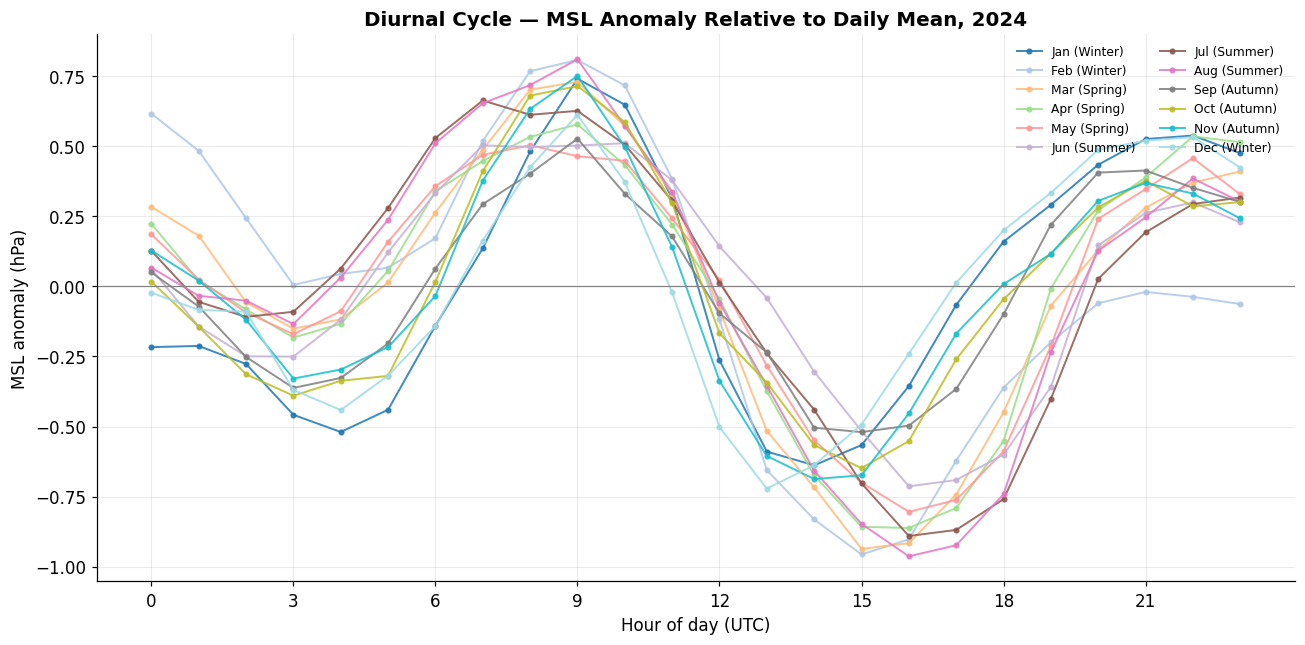

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

for month in months:
    d = data_msl[month]
    ts = np.nanmean(d['samples'], axis=0)
    n_full_days = len(ts) // 24
    ts_days = ts[:n_full_days * 24].reshape(n_full_days, 24)

    diurnal_mean = ts_days.mean(axis=0)
    anomaly = diurnal_mean - diurnal_mean.mean()

    hours = np.arange(24)
    ax.plot(hours, anomaly, marker='o', markersize=3,
            color=MONTH_COLORS[month], linewidth=1.3, alpha=0.85,
            label=f'{month[:3]} ({d["season"]})')

ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('MSL anomaly (hPa)')
ax.set_title('Diurnal Cycle — MSL Anomaly Relative to Daily Mean, 2024')
ax.legend(loc='upper right', ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig('msl_diurnal_cycle_2024.png', bbox_inches='tight')
plt.show()

## 7bis. Diurnal Cycle — Average i10fg by Hour of Day

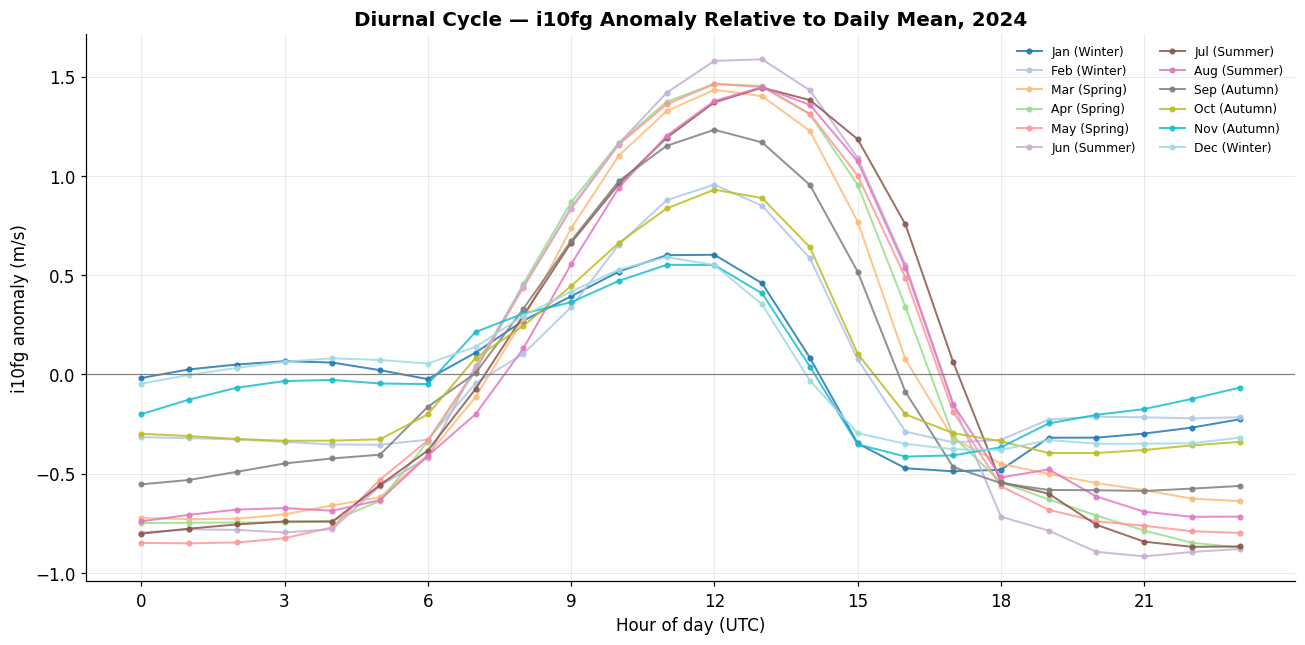

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

for month in months:
    d = data_i10fg[month]
    ts = np.nanmean(d['samples'], axis=0)
    n_full_days = len(ts) // 24
    ts_days = ts[:n_full_days * 24].reshape(n_full_days, 24)

    diurnal_mean = ts_days.mean(axis=0)
    anomaly = diurnal_mean - diurnal_mean.mean()

    hours = np.arange(24)
    ax.plot(hours, anomaly, marker='o', markersize=3,
            color=MONTH_COLORS[month], linewidth=1.3, alpha=0.85,
            label=f'{month[:3]} ({d["season"]})')

ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('i10fg anomaly (m/s)')
ax.set_title('Diurnal Cycle — i10fg Anomaly Relative to Daily Mean, 2024')
ax.legend(loc='upper right', ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig('i10fg_diurnal_cycle_2024.png', bbox_inches='tight')
plt.show()

## 8. Spatial Maps — Seasonal Mean MSL Field

The time-averaged pressure field reconstructed on the spatial grid, one map per season.

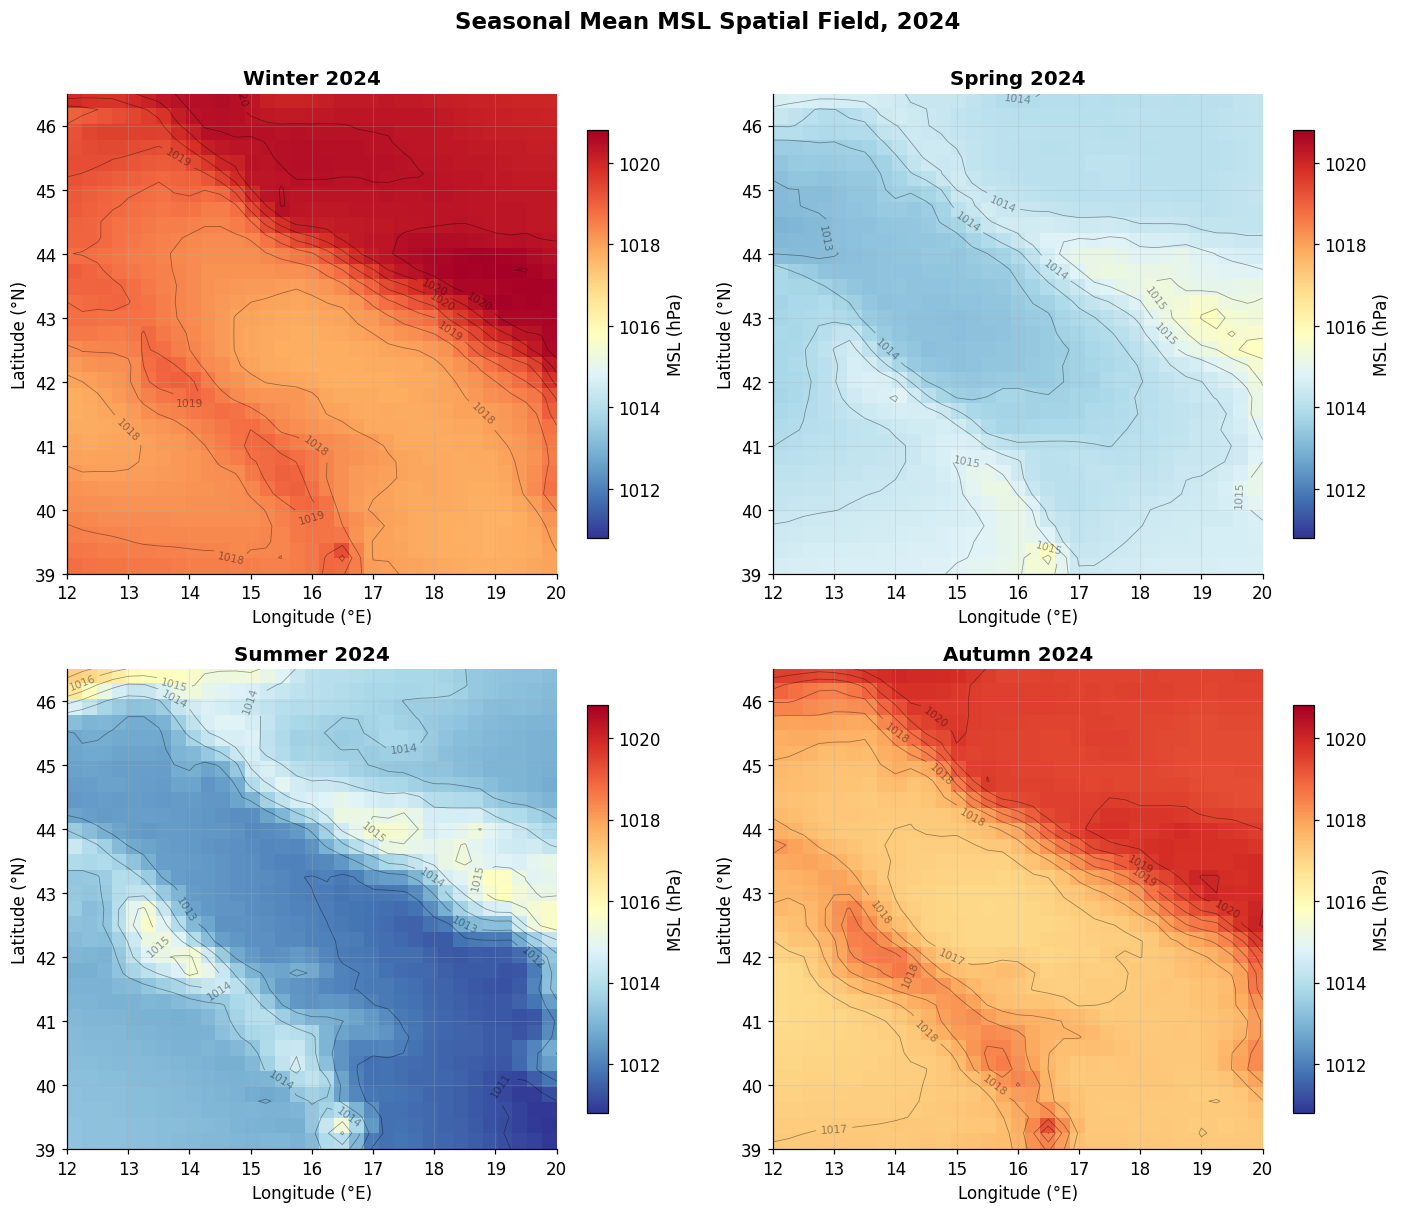

In [19]:
def to_grid(values, lon, lat):
    valid = ~(np.isnan(lon) | np.isnan(lat))
    values, lon, lat = values[valid], lon[valid], lat[valid]
    lons_u = np.sort(np.unique(lon))
    lats_u = np.sort(np.unique(lat))[::-1]
    grid = np.full((len(lats_u), len(lons_u)), np.nan)
    lon_idx = {v: i for i, v in enumerate(lons_u)}
    lat_idx = {v: i for i, v in enumerate(lats_u)}
    for v, lo, la in zip(values, lon, lat):
        grid[lat_idx[la], lon_idx[lo]] = v
    return grid, lons_u, lats_u

# Pool months by season for the spatial mean
season_means_msl = {}
for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    months_in_season = [m for m in months if data_msl[m]['season'] == season]
    pooled_samples = np.concatenate([data_msl[m]['samples'] for m in months_in_season], axis=1)
    season_means_msl[season] = np.nanmean(pooled_samples, axis=1)

all_means = list(season_means_msl.values())
vmin = min(np.nanmin(m) for m in all_means)
vmax = max(np.nanmax(m) for m in all_means)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, season in zip(axes, ['Winter', 'Spring', 'Summer', 'Autumn']):
    grid, lons_u, lats_u = to_grid(season_means_msl[season], lon_flat, lat_flat)

    im = ax.imshow(grid, cmap='RdYlBu_r', vmin=vmin, vmax=vmax,
                   extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                   aspect='auto', origin='upper')
    cs = ax.contour(grid, levels=8, colors='black', linewidths=0.5, alpha=0.4,
                    extent=[LON_MIN, LON_MAX, LAT_MAX, LAT_MIN])
    ax.clabel(cs, inline=True, fontsize=7, fmt='%.0f')
    ax.set_title(f'{season} 2024')
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
    plt.colorbar(im, ax=ax, label='MSL (hPa)', shrink=0.85)

fig.suptitle('Seasonal Mean MSL Spatial Field, 2024', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('msl_spatial_maps_2024.png', bbox_inches='tight')
plt.show()

## 8bis. Spatial Maps — Seasonal Mean i10fg Field

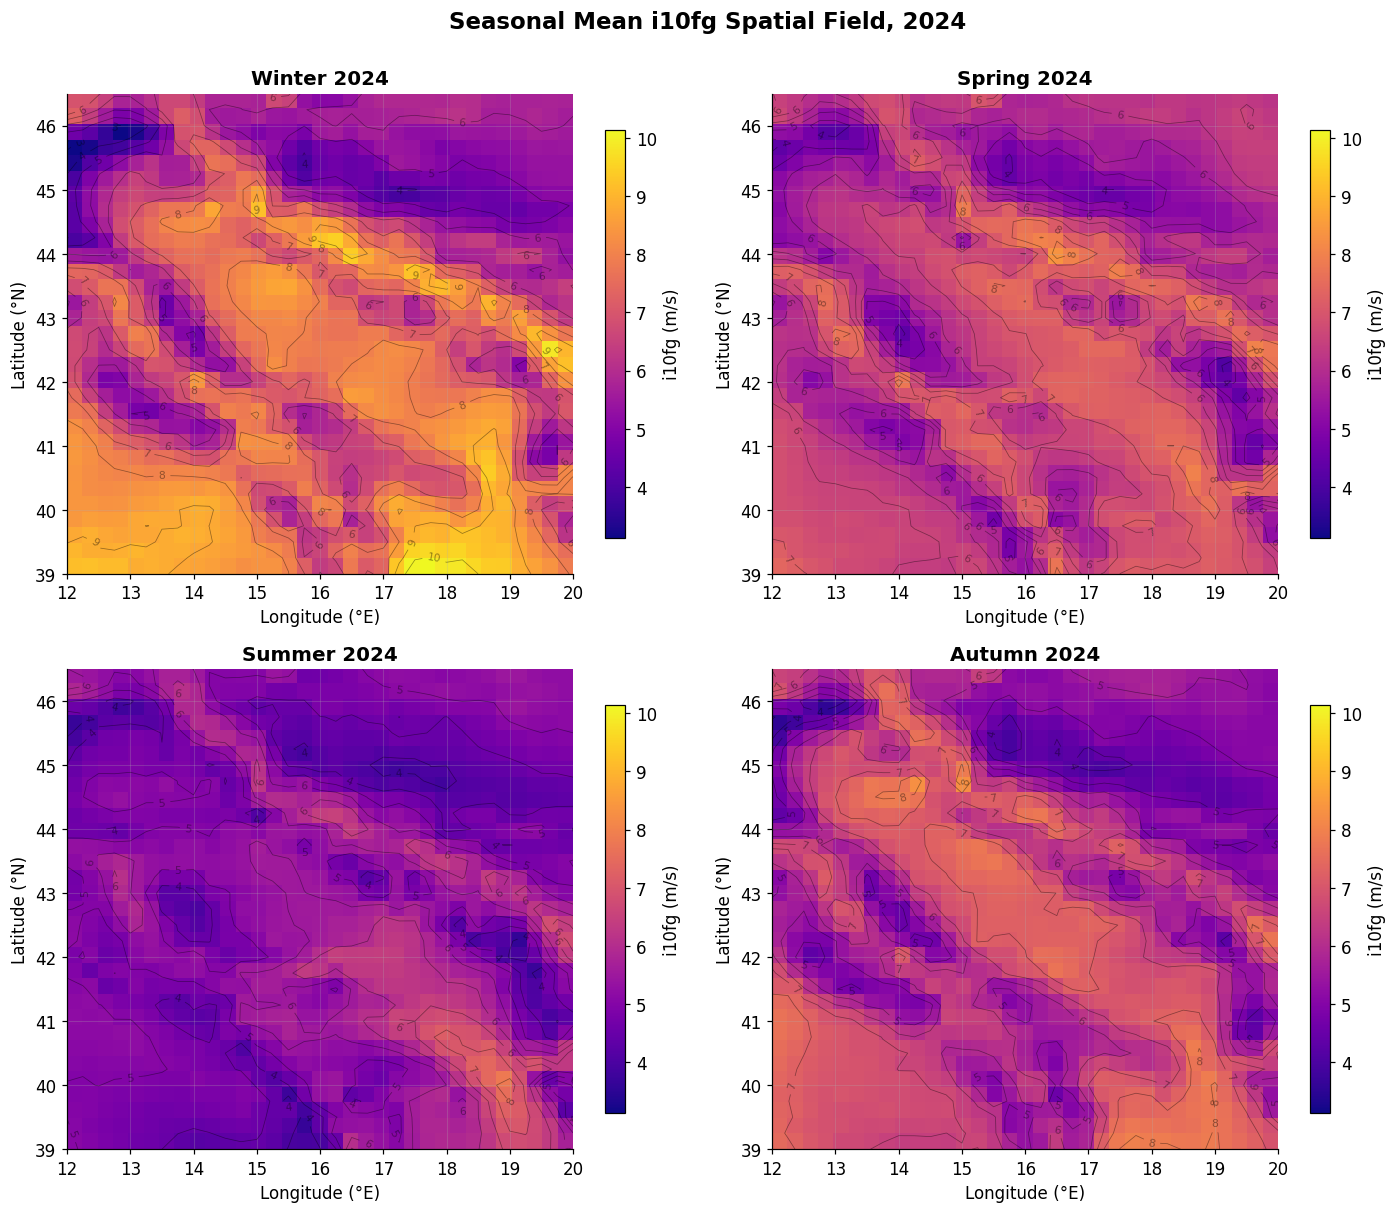

In [20]:
season_means_i10fg = {}
for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    months_in_season = [m for m in months if data_i10fg[m]['season'] == season]
    pooled_samples = np.concatenate([data_i10fg[m]['samples'] for m in months_in_season], axis=1)
    season_means_i10fg[season] = np.nanmean(pooled_samples, axis=1)

all_means = list(season_means_i10fg.values())
vmin = min(np.nanmin(m) for m in all_means)
vmax = max(np.nanmax(m) for m in all_means)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, season in zip(axes, ['Winter', 'Spring', 'Summer', 'Autumn']):
    grid, lons_u, lats_u = to_grid(season_means_i10fg[season], lon_flat, lat_flat)

    im = ax.imshow(grid, cmap='plasma', vmin=vmin, vmax=vmax,
                   extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                   aspect='auto', origin='upper')
    cs = ax.contour(grid, levels=8, colors='black', linewidths=0.5, alpha=0.4,
                    extent=[LON_MIN, LON_MAX, LAT_MAX, LAT_MIN])
    ax.clabel(cs, inline=True, fontsize=7, fmt='%.0f')
    ax.set_title(f'{season} 2024')
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
    plt.colorbar(im, ax=ax, label='i10fg (m/s)', shrink=0.85)

fig.suptitle('Seasonal Mean i10fg Spatial Field, 2024', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('i10fg_spatial_maps_2024.png', bbox_inches='tight')
plt.show()

## 9. Spatial Variability — Standard Deviation Maps (MSL)

Where does pressure vary most over time within each season? High-variability regions indicate areas swept by moving fronts and synoptic systems.

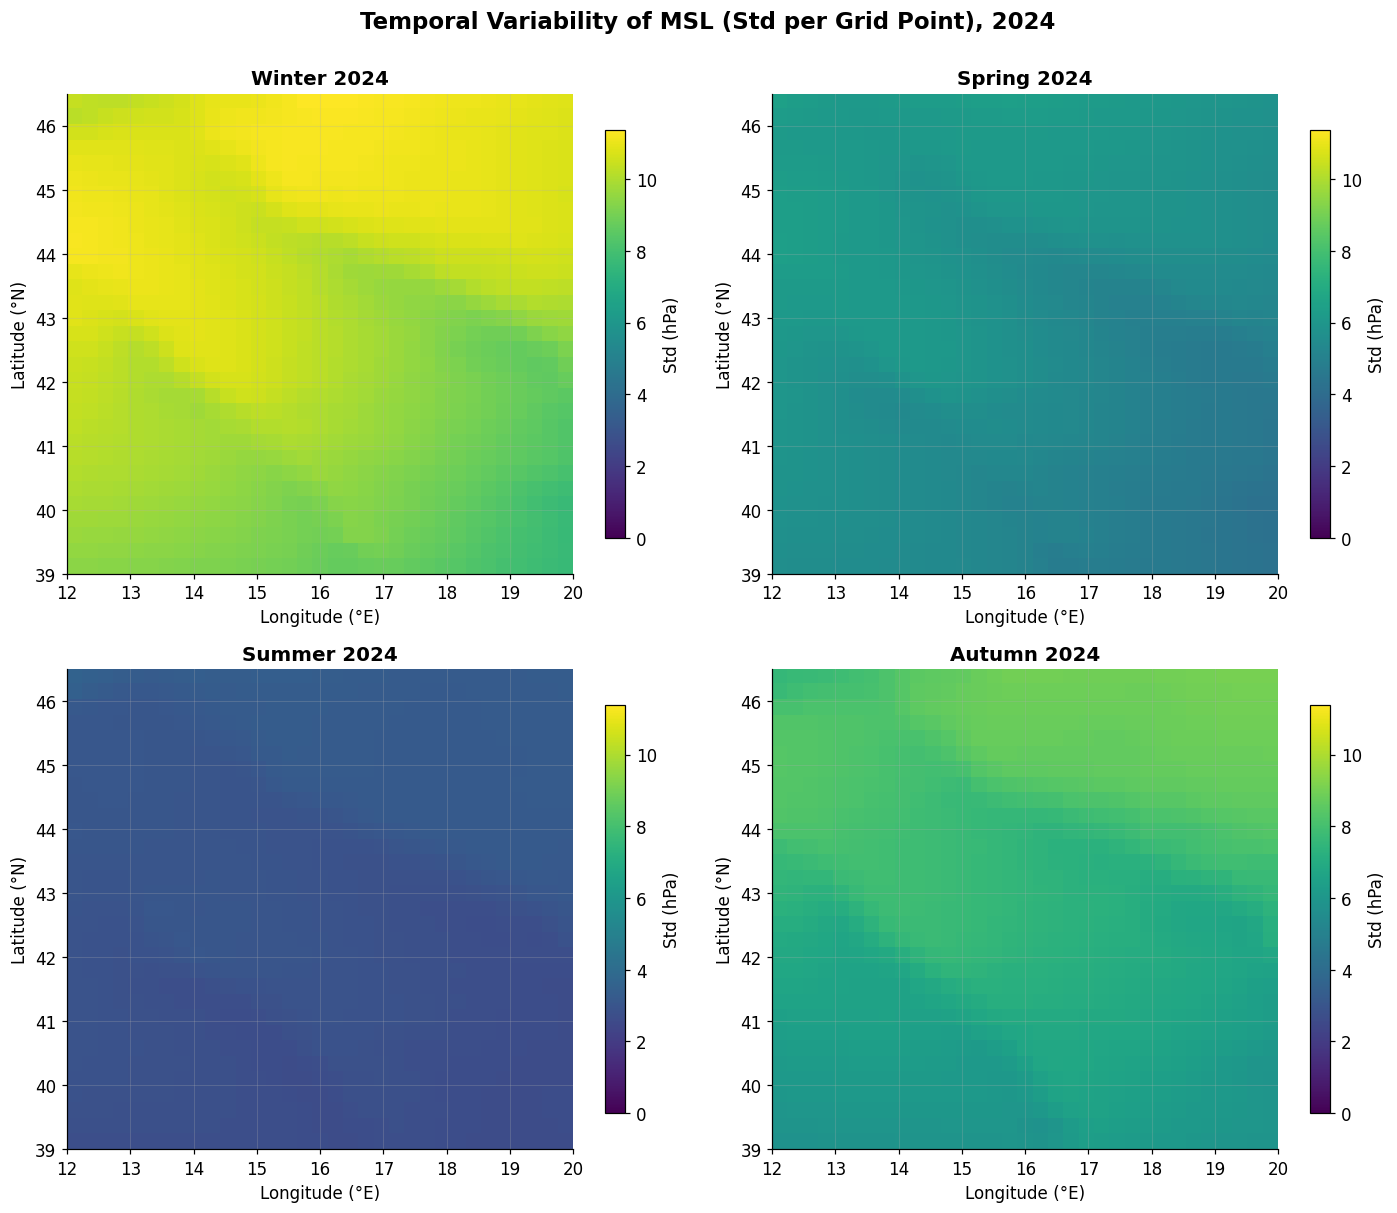

In [21]:
season_stds_msl = {}
for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    months_in_season = [m for m in months if data_msl[m]['season'] == season]
    pooled_samples = np.concatenate([data_msl[m]['samples'] for m in months_in_season], axis=1)
    season_stds_msl[season] = np.nanstd(pooled_samples, axis=1)

smax = max(np.nanmax(s) for s in season_stds_msl.values())

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, season in zip(axes, ['Winter', 'Spring', 'Summer', 'Autumn']):
    grid, lons_u, lats_u = to_grid(season_stds_msl[season], lon_flat, lat_flat)

    im = ax.imshow(grid, cmap='viridis', vmin=0, vmax=smax,
                   extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                   aspect='auto', origin='upper')
    ax.set_title(f'{season} 2024')
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
    plt.colorbar(im, ax=ax, label='Std (hPa)', shrink=0.85)

fig.suptitle('Temporal Variability of MSL (Std per Grid Point), 2024',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('msl_variability_maps_2024.png', bbox_inches='tight')
plt.show()

## 9bis. Spatial Variability — Standard Deviation Maps (i10fg)

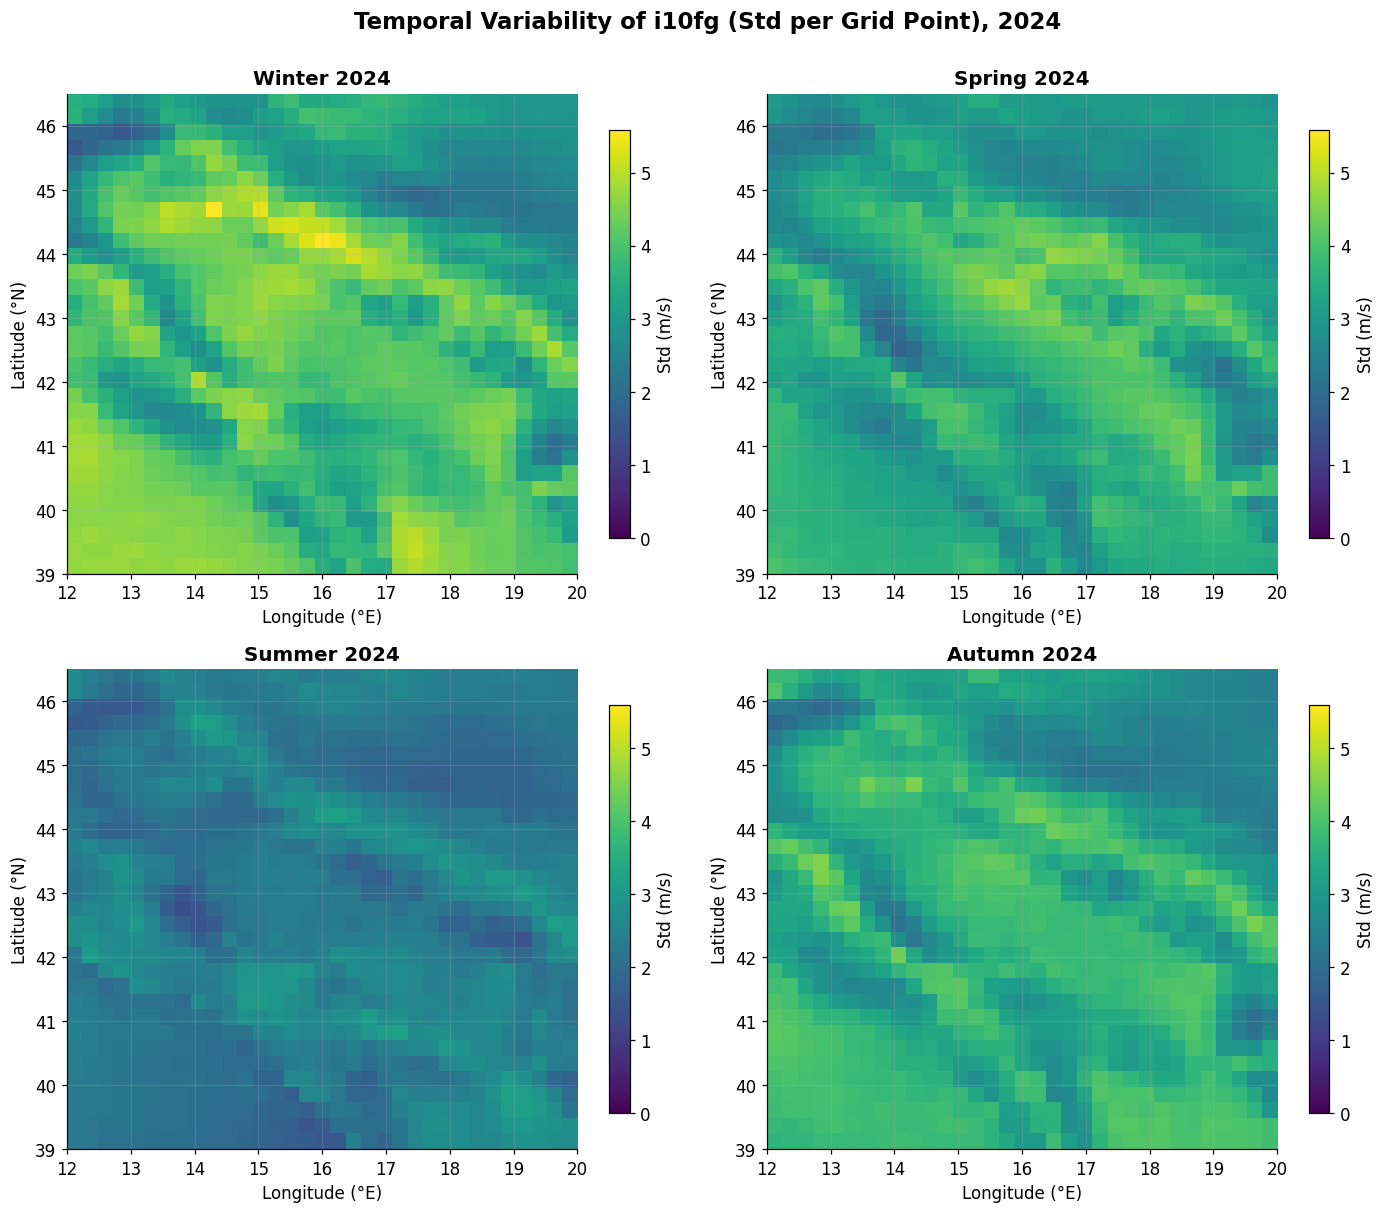

In [22]:
season_stds_i10fg = {}
for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    months_in_season = [m for m in months if data_i10fg[m]['season'] == season]
    pooled_samples = np.concatenate([data_i10fg[m]['samples'] for m in months_in_season], axis=1)
    season_stds_i10fg[season] = np.nanstd(pooled_samples, axis=1)

smax = max(np.nanmax(s) for s in season_stds_i10fg.values())

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, season in zip(axes, ['Winter', 'Spring', 'Summer', 'Autumn']):
    grid, lons_u, lats_u = to_grid(season_stds_i10fg[season], lon_flat, lat_flat)

    im = ax.imshow(grid, cmap='viridis', vmin=0, vmax=smax,
                   extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                   aspect='auto', origin='upper')
    ax.set_title(f'{season} 2024')
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
    plt.colorbar(im, ax=ax, label='Std (m/s)', shrink=0.85)

fig.suptitle('Temporal Variability of i10fg (Std per Grid Point), 2024',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('i10fg_variability_maps_2024.png', bbox_inches='tight')
plt.show()

## 10. Seasonal Aggregation — All Four Seasons (MSL)

Pooling months by season to compare the overall pressure regime across Winter, Spring, Summer, and Autumn.

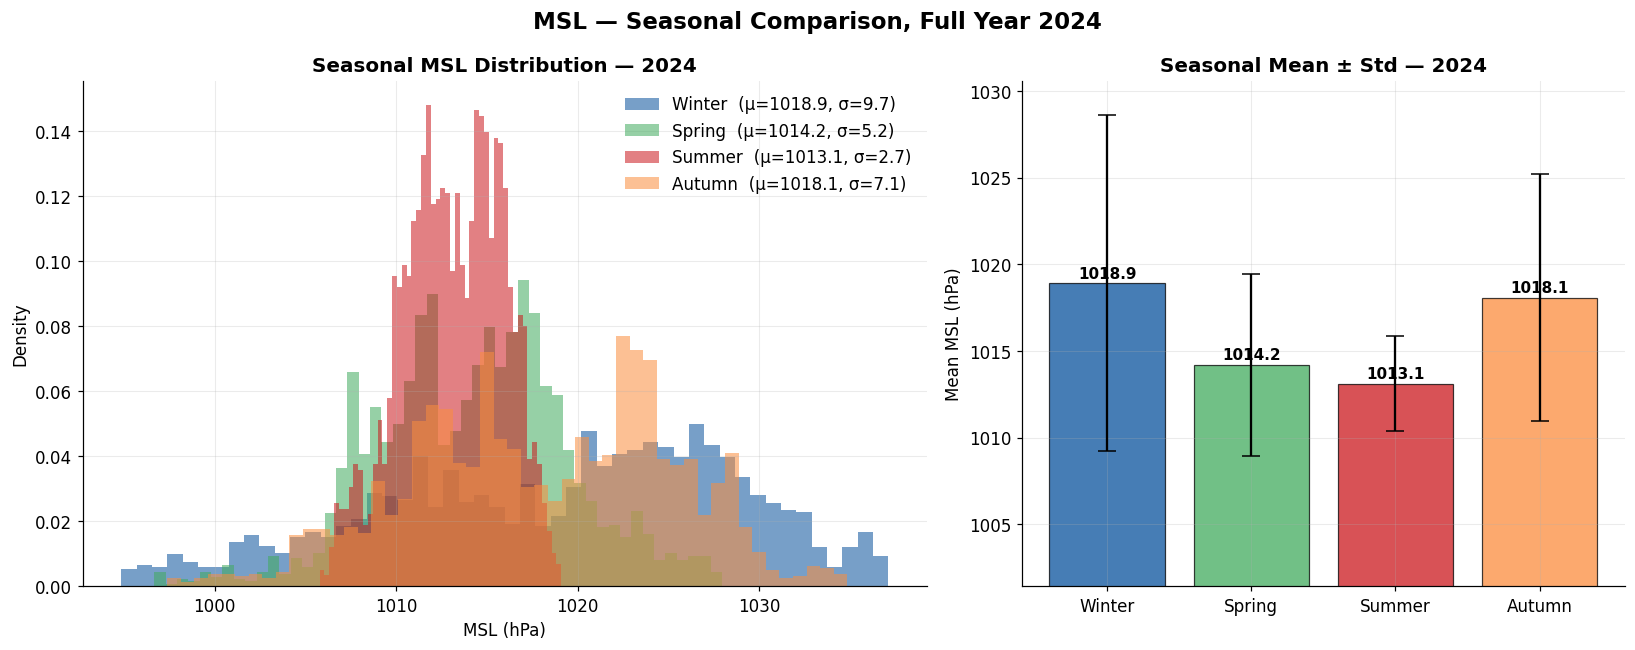

In [23]:
season_ts_msl = {}
for month in months:
    s = data_msl[month]['season']
    ts = np.nanmean(data_msl[month]['samples'], axis=0)
    season_ts_msl.setdefault(s, []).append(ts)

season_pooled_msl = {s: np.concatenate(v) for s, v in season_ts_msl.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.4, 1]})

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
for s in season_order:
    pooled = season_pooled_msl[s]
    ax1.hist(pooled, bins=50, alpha=0.55, density=True,
             color=SEASON_COLORS[s],
             label=f'{s}  (μ={pooled.mean():.1f}, σ={pooled.std():.1f})')
ax1.set_xlabel('MSL (hPa)')
ax1.set_ylabel('Density')
ax1.set_title('Seasonal MSL Distribution — 2024')
ax1.legend()

s_means = [season_pooled_msl[s].mean() for s in season_order]
s_stds  = [season_pooled_msl[s].std()  for s in season_order]
bars = ax2.bar(season_order, s_means, yerr=s_stds, capsize=6,
               color=[SEASON_COLORS[s] for s in season_order],
               alpha=0.75, edgecolor='black', linewidth=0.8)
ax2.set_ylabel('Mean MSL (hPa)')
ax2.set_title('Seasonal Mean ± Std — 2024')
ax2.set_ylim(min(s_means) - max(s_stds) - 2, max(s_means) + max(s_stds) + 2)
for bar, m in zip(bars, s_means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{m:.1f}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('MSL — Seasonal Comparison, Full Year 2024',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('msl_seasonal_comparison_2024.png', bbox_inches='tight')
plt.show()

## 10bis. Seasonal Aggregation — All Four Seasons (i10fg)

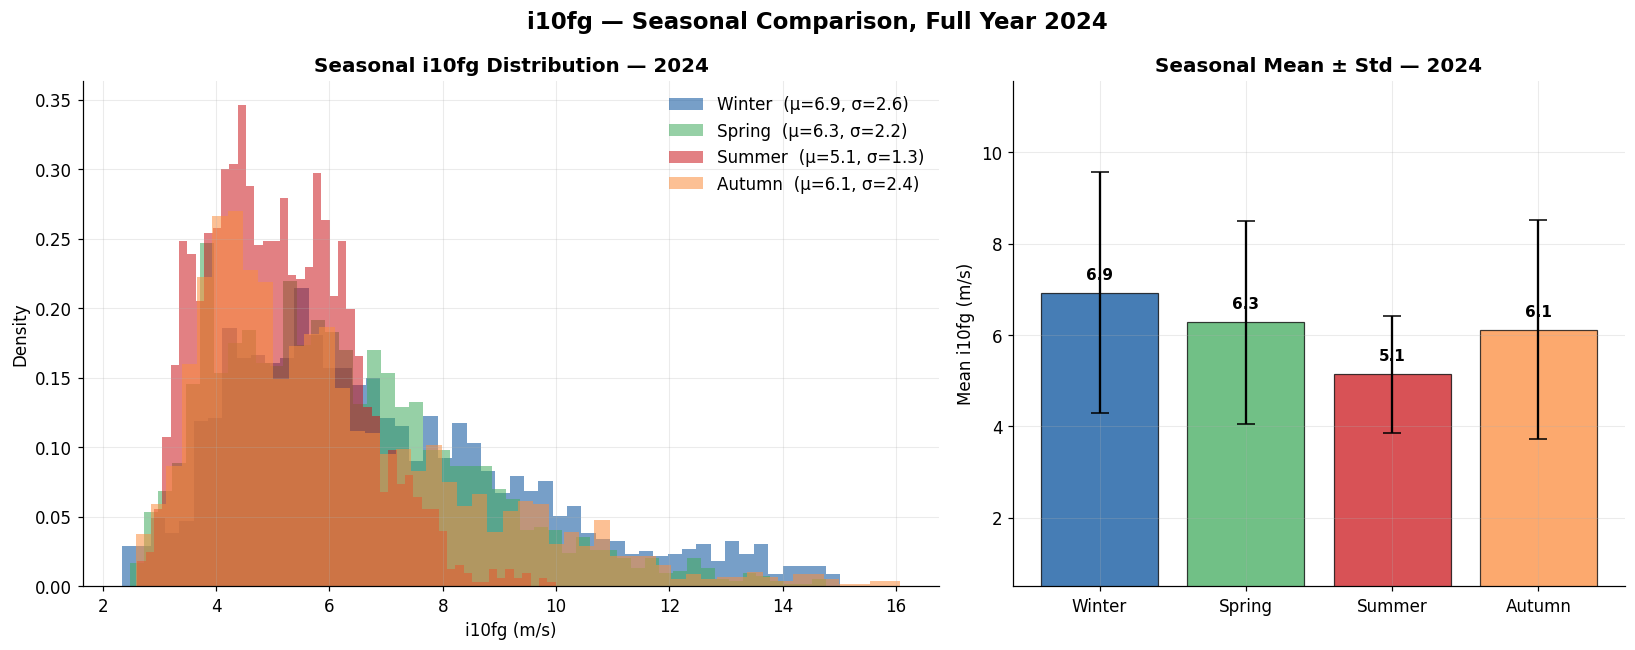

In [24]:
season_ts_i10fg = {}
for month in months:
    s = data_i10fg[month]['season']
    ts = np.nanmean(data_i10fg[month]['samples'], axis=0)
    season_ts_i10fg.setdefault(s, []).append(ts)

season_pooled_i10fg = {s: np.concatenate(v) for s, v in season_ts_i10fg.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.4, 1]})

for s in season_order:
    pooled = season_pooled_i10fg[s]
    ax1.hist(pooled, bins=50, alpha=0.55, density=True,
             color=SEASON_COLORS[s],
             label=f'{s}  (μ={pooled.mean():.1f}, σ={pooled.std():.1f})')
ax1.set_xlabel('i10fg (m/s)')
ax1.set_ylabel('Density')
ax1.set_title('Seasonal i10fg Distribution — 2024')
ax1.legend()

s_means = [season_pooled_i10fg[s].mean() for s in season_order]
s_stds  = [season_pooled_i10fg[s].std()  for s in season_order]
bars = ax2.bar(season_order, s_means, yerr=s_stds, capsize=6,
               color=[SEASON_COLORS[s] for s in season_order],
               alpha=0.75, edgecolor='black', linewidth=0.8)
ax2.set_ylabel('Mean i10fg (m/s)')
ax2.set_title('Seasonal Mean ± Std — 2024')
ax2.set_ylim(min(s_means) - max(s_stds) - 2, max(s_means) + max(s_stds) + 2)
for bar, m in zip(bars, s_means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{m:.1f}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('i10fg — Seasonal Comparison, Full Year 2024',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('i10fg_seasonal_comparison_2024.png', bbox_inches='tight')
plt.show()

## 11. Key Findings — MSL

Auto-generated summary of the full-year seasonal analysis.

In [25]:
print('='*60)
print('  MSL SEASONAL ANALYSIS — KEY FINDINGS (2024)')
print('='*60)

var_by_month = {m: np.nanmean(data_msl[m]['samples'], axis=0).std() for m in months}
most_var  = max(var_by_month, key=var_by_month.get)
least_var = min(var_by_month, key=var_by_month.get)

mean_by_month = {m: np.nanmean(data_msl[m]['samples']) for m in months}
high_m = max(mean_by_month, key=mean_by_month.get)
low_m  = min(mean_by_month, key=mean_by_month.get)

print(f'\n  Temporal variability (synoptic activity):')
print(f'    Most variable : {most_var}  (σ={var_by_month[most_var]:.2f} hPa)')
print(f'    Least variable: {least_var}  (σ={var_by_month[least_var]:.2f} hPa)')

print(f'\n  Mean pressure level:')
print(f'    Highest: {high_m}  ({mean_by_month[high_m]:.2f} hPa)')
print(f'    Lowest : {low_m}  ({mean_by_month[low_m]:.2f} hPa)')

print(f'\n  Seasonal means (full year 2024):')
for s in ['Winter', 'Spring', 'Summer', 'Autumn']:
    pooled = season_pooled_msl[s]
    print(f'    {s:7s}: {pooled.mean():.2f} ± {pooled.std():.2f} hPa')

print(f'\n  Generated figures:')
for f in ['msl_monthly_timeseries_2024', 'msl_aggregated_timeline_2024',
          'msl_distributions_2024', 'msl_diurnal_cycle_2024',
          'msl_spatial_maps_2024', 'msl_variability_maps_2024',
          'msl_seasonal_comparison_2024']:
    print(f'    - {f}.png')
print('='*60)

  MSL SEASONAL ANALYSIS — KEY FINDINGS (2024)

  Temporal variability (synoptic activity):
    Most variable : January  (σ=10.95 hPa)
    Least variable: July  (σ=2.62 hPa)

  Mean pressure level:
    Highest: November  (1021.68 hPa)
    Lowest : July  (1012.70 hPa)

  Seasonal means (full year 2024):
    Winter : 1018.92 ± 9.69 hPa
    Spring : 1014.20 ± 5.25 hPa
    Summer : 1013.11 ± 2.74 hPa
    Autumn : 1018.07 ± 7.13 hPa

  Generated figures:
    - msl_monthly_timeseries_2024.png
    - msl_aggregated_timeline_2024.png
    - msl_distributions_2024.png
    - msl_diurnal_cycle_2024.png
    - msl_spatial_maps_2024.png
    - msl_variability_maps_2024.png
    - msl_seasonal_comparison_2024.png


## 11bis. Key Findings — i10fg

In [26]:
print('='*60)
print('  I10FG SEASONAL ANALYSIS — KEY FINDINGS (2024)')
print('='*60)

var_by_month = {m: np.nanmean(data_i10fg[m]['samples'], axis=0).std() for m in months}
most_var  = max(var_by_month, key=var_by_month.get)
least_var = min(var_by_month, key=var_by_month.get)

mean_by_month = {m: np.nanmean(data_i10fg[m]['samples']) for m in months}
high_m = max(mean_by_month, key=mean_by_month.get)
low_m  = min(mean_by_month, key=mean_by_month.get)

print(f'\n  Temporal variability:')
print(f'    Most variable : {most_var}  (σ={var_by_month[most_var]:.2f} m/s)')
print(f'    Least variable: {least_var}  (σ={var_by_month[least_var]:.2f} m/s)')

print(f'\n  Mean gust level:')
print(f'    Highest: {high_m}  ({mean_by_month[high_m]:.2f} m/s)')
print(f'    Lowest : {low_m}  ({mean_by_month[low_m]:.2f} m/s)')

print(f'\n  Seasonal means (full year 2024):')
for s in ['Winter', 'Spring', 'Summer', 'Autumn']:
    pooled = season_pooled_i10fg[s]
    print(f'    {s:7s}: {pooled.mean():.2f} ± {pooled.std():.2f} m/s')

print(f'\n  Generated figures:')
for f in ['i10fg_monthly_timeseries_2024', 'i10fg_aggregated_timeline_2024',
          'i10fg_distributions_2024', 'i10fg_diurnal_cycle_2024',
          'i10fg_spatial_maps_2024', 'i10fg_variability_maps_2024',
          'i10fg_seasonal_comparison_2024']:
    print(f'    - {f}.png')
print('='*60)

  I10FG SEASONAL ANALYSIS — KEY FINDINGS (2024)

  Temporal variability:
    Most variable : December  (σ=3.12 m/s)
    Least variable: August  (σ=1.09 m/s)

  Mean gust level:
    Highest: December  (7.11 m/s)
    Lowest : August  (4.79 m/s)

  Seasonal means (full year 2024):
    Winter : 6.93 ± 2.64 m/s
    Spring : 6.28 ± 2.22 m/s
    Summer : 5.14 ± 1.28 m/s
    Autumn : 6.11 ± 2.39 m/s

  Generated figures:
    - i10fg_monthly_timeseries_2024.png
    - i10fg_aggregated_timeline_2024.png
    - i10fg_distributions_2024.png
    - i10fg_diurnal_cycle_2024.png
    - i10fg_spatial_maps_2024.png
    - i10fg_variability_maps_2024.png
    - i10fg_seasonal_comparison_2024.png
